# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [50]:
%load_ext autoreload
%autoreload 2

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from itertools import product


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading

In [51]:
loader = HW3DataLoader()
X_clf, y_clf = loader.get_heart_disease_data('../data/heart.csv')
df_aging = loader.get_aging_data('../data/GSE139307.pkl')

# TODO: Inspect dataset shapes and missing values
# TODO: Print basic summary statistics for each dataset

print("Heart Disease Dataset:")
print(f"Shape: {X_clf.shape}")
print(f"Class Balance:\n{y_clf.value_counts()}")
print(f"Missing Values: {X_clf.isnull().sum().sum()}")
print(f"Feature Distributions:\n{X_clf.describe()}")
print(f"Duplicate Rows: {X_clf.duplicated().sum()}")


print("\nGenomic Aging Dataset:")
print(f"Heading names: {df_aging.columns}")
print(f"Shape: {df_aging.shape}")
print(f"Missing Values: {df_aging.isnull().sum().sum()}")
print(f"Feature Distributions:\n{df_aging['age'].describe()}")
# print(f"Duplicate Rows: {df_aging.duplicated().sum()}")
# no duplicates + takes forever



Successfully loaded heart disease data with 1025 rows
Heart Disease Dataset:
Shape: (1025, 13)
Class Balance:
target
1    526
0    499
Name: count, dtype: int64
Missing Values: 0
Feature Distributions:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00

## Classification Task (Heart Disease)

Exploring classification dataset...


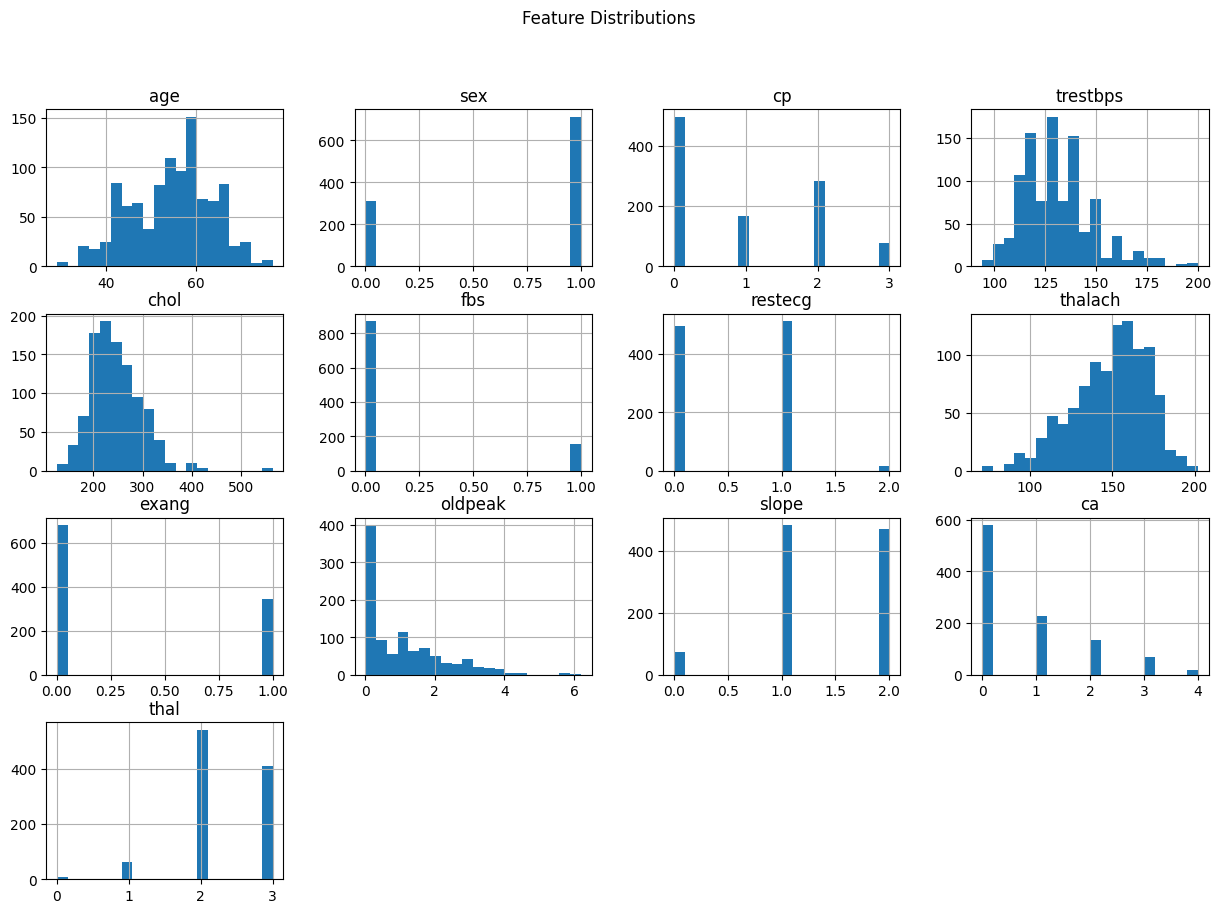

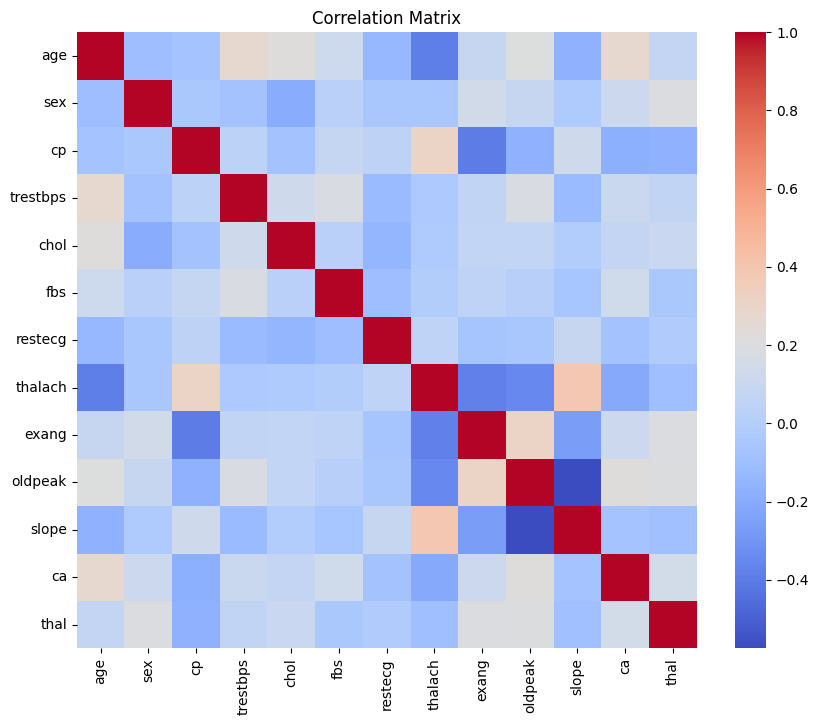

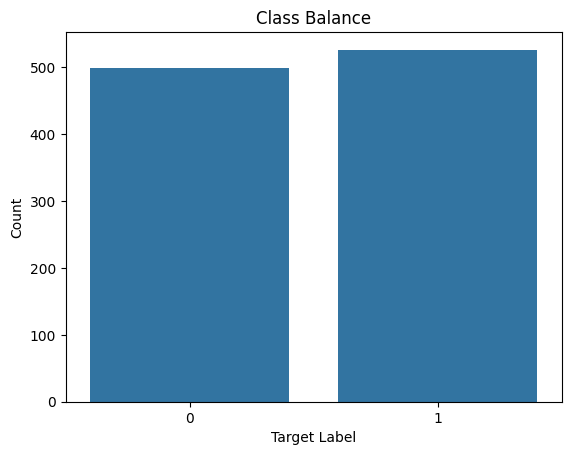

In [52]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils
explore_classification_data(X_clf, y_clf)


In [115]:
# TODO: Split X_clf and y_clf into training and testing sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, random_state=42, stratify=y_clf)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [ ]:
# TODO: Build a leakage-free pipeline for classification
# Example skeleton:
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_classifier(kernel=..., C=..., degree=..., gamma=...)),
# ])

# done below within the kernel loop!

### Kernel Experiments

In [126]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model

kernels = ["linear", "poly", "rbf"]
results = {}
for kernel in kernels:
    if kernel == "linear":
        model = svm_classifier(kernel=kernel, C=10)
    elif kernel == "poly":
        model = svm_classifier(kernel=kernel, C=100, degree=5)
    elif kernel == "rbf":
        model = svm_classifier(kernel=kernel, C=100, gamma=1)

    pipeline = Pipeline([      
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("model",   model),
    ])
    pipeline.fit(X_train_clf, y_train_clf)
    y_pred = pipeline.predict(X_test_clf)
    scores  = pipeline.decision_function(X_test_clf)

    acc, precision, recall, f1 = evaluate_classifier(pipeline, X_test_clf, y_test_clf)
    roc_auc = roc_auc_score(y_test_clf, scores)
    
    results[kernel] = dict(
        pipeline=pipeline, y_pred=y_pred, scores=scores,
        accuracy=acc, f1=f1, roc_auc=roc_auc,
    )

for kernel, metrics in results.items():
    print(f"{kernel} - Accuracy: {metrics['accuracy']}, F1: {metrics['f1']}, ROC AUC: {metrics['roc_auc']}")
    

linear - Accuracy: 0.8404669260700389, F1: 0.8390296251051907, ROC AUC: 0.9168484848484848
poly - Accuracy: 1.0, F1: 1.0, ROC AUC: 1.0
rbf - Accuracy: 1.0, F1: 1.0, ROC AUC: 1.0


### Classification Metrics and Visuals

/Users/brookewangenheim/Desktop/CURRENT/homework-3-brwangenheim/.hw3/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/Users/brookewangenheim/Desktop/CURRENT/homework-3-brwangenheim/.hw3/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/Users/brookewangenheim/Desktop/CURRENT/homework-3-brwangenheim/.hw3/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


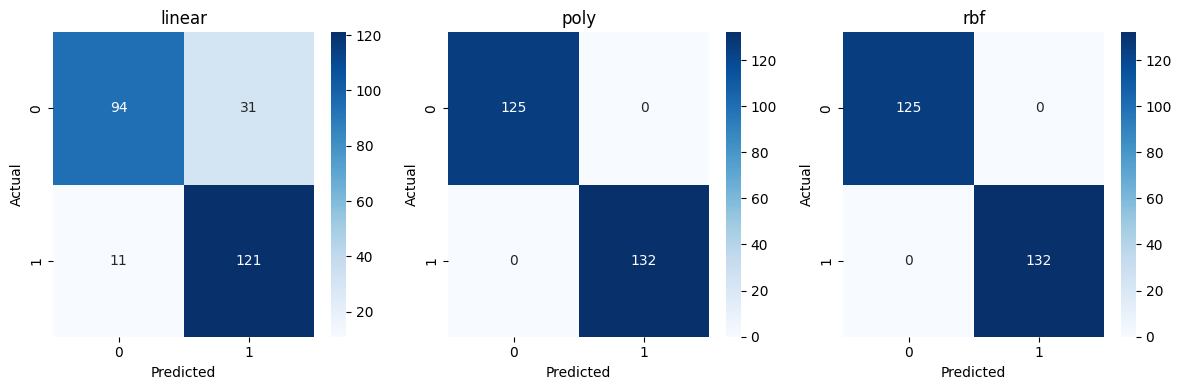

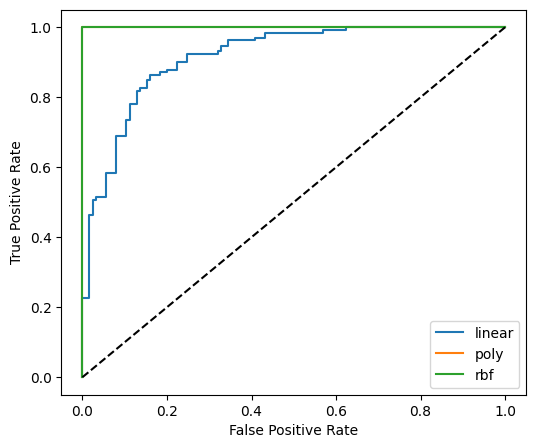

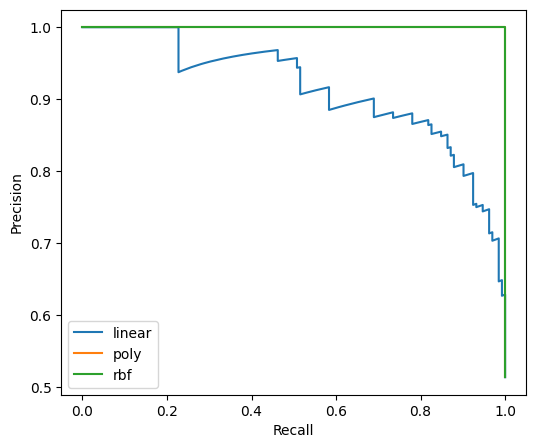

In [117]:
# TODO: Compute accuracy and F1
# done above !
for kernel, m in results.items():
    plot_classification_results(
        X=X_train_clf,
        y=y_train_clf,
        model=m["pipeline"],
        filename=f"clf_boundary_{kernel}.png",
        title=f"Decision Boundary — {kernel} kernel",
    )
    plt.show()

# TODO: Compute ROC-AUC or PR-AUC
# TODO: Plot confusion matrix and ROC/PR curve

# confusion matrix:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (kernel, m) in zip(axes, results.items()):
    cm = confusion_matrix(y_test_clf, m["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(kernel)
plt.tight_layout()
plt.savefig("clf_confusion_matrices.png")
plt.show()

# roc curve:
plt.figure(figsize=(6, 5))
for kernel, m in results.items():
    fpr, tpr, _ = roc_curve(y_test_clf, m["scores"])
    plt.plot(fpr, tpr, label=kernel)
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("clf_roc_curves.png")
plt.show()

# pr curve:
plt.figure(figsize=(6, 5))
for kernel, m in results.items():
    prec, rec, _ = precision_recall_curve(y_test_clf, m["scores"])
    plt.plot(rec, prec, label=kernel)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.savefig("clf_pr_curves.png")
plt.show()


### Hyperparameter Sensitivity

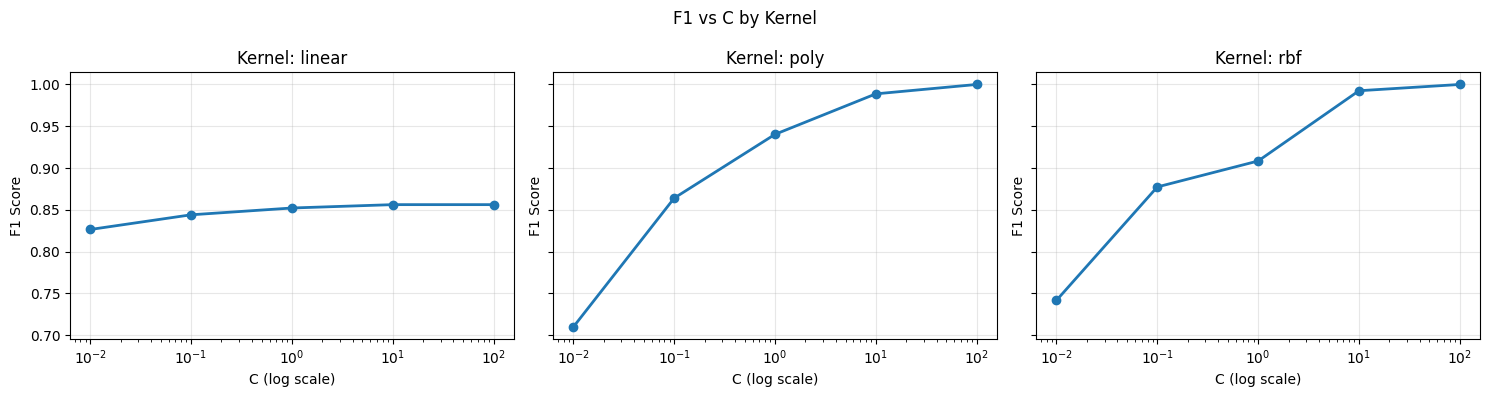

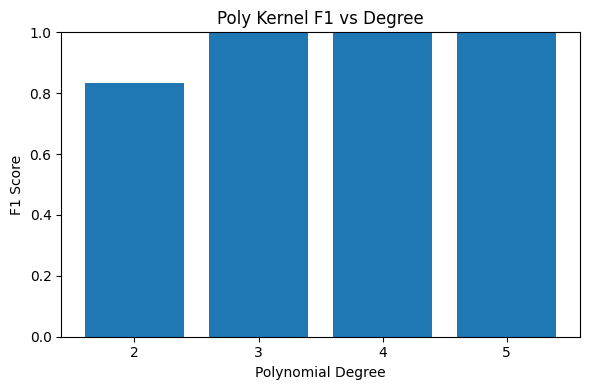

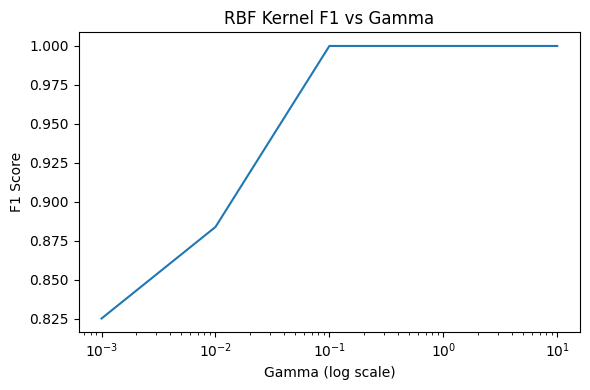

In [ ]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree
# Example: line plot of F1 vs C for a fixed kernel

# f1 vs C
C_values = [0.01, 0.1, 1, 10, 100]
kernel_configs = {
    "linear": dict(kernel="linear"),
    "poly":   dict(kernel="poly", degree=3),
    "rbf":    dict(kernel="rbf", gamma=1),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("F1 vs C by Kernel")

for ax, (name, params) in zip(axes, kernel_configs.items()):
    f1_scores = []
    for C in C_values:
        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler",  StandardScaler()),
            ("model",   svm_classifier(C=C, **params)),
        ])
        pipeline.fit(X_train_clf, y_train_clf)
        f1_scores.append(f1_score(y_test_clf, pipeline.predict(X_test_clf)))
    ax.plot(C_values, f1_scores, marker="o", linewidth=2)
    ax.set_xscale("log")
    ax.set_xlabel("C (log scale)")
    ax.set_ylabel("F1 Score")
    ax.set_title(f"Kernel: {name}")

plt.tight_layout()
plt.savefig("clf_C_sensitivity.png")
plt.show()

# f1 vs degree for poly kernel
degrees = [2, 3, 4, 5]
f1_by_degree = []

for d in degrees:
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("model",   svm_classifier(kernel="poly", C=100, degree=d)),
    ])
    pipeline.fit(X_train_clf, y_train_clf)
    f1_by_degree.append(f1_score(y_test_clf, pipeline.predict(X_test_clf)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(d) for d in degrees], f1_by_degree)
ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("F1 Score")
ax.set_title("Poly Kernel F1 vs Degree")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("clf_poly_degree_sensitivity.png")
plt.show()

gamma_values_plot = [0.001, 0.01, 0.1, 1, 10]

f1_by_gamma = []
for g in gamma_values_plot:
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("model",   svm_classifier(kernel="rbf", C=10.0, gamma=g)),
    ])
    pipeline.fit(X_train_clf, y_train_clf)
    f1_by_gamma.append(f1_score(y_test_clf, pipeline.predict(X_test_clf)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(gamma_values_plot, f1_by_gamma)
ax.set_xscale("log")
ax.set_xlabel("Gamma (log scale)")
ax.set_ylabel("F1 Score")
ax.set_title("RBF Kernel F1 vs Gamma")
plt.tight_layout()
plt.savefig("clf_gamma_sensitivity.png")
plt.show()


## Regression Task (Biological Aging)

In [124]:
# TODO: Separate target column "target" from features
X_reg = df_aging.drop(columns=["age", "tissue_type", "gender", "dataset", "cg01550828"])
y_reg = df_aging["age"]

# TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)

# TODO: Split X_reg and y_reg into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, random_state=42)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

In [ ]:
# TODO: Build a leakage-free pipeline for regression

# done below for each kernel!

### Kernel Experiments

In [ ]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]

kernels = ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
C_values = [0.1, 1.0, 10.0]
degree_values = [2, 3, 4] # just for poly
gamma_values = [0.01, 0.1, 1] # just for rbf

reg_results = []

for kernel in kernels:
    # there's probably a more efficient way to do this but that's okay
    # linear
    if kernel == "linear":
        for C in C_values:
            model = svm_regressor(kernel=kernel, C=C)
            pipeline = Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=10)),
                ("model", model)
            ])
            scores = cross_val_score(pipeline, X_reg, y_reg, cv=5, scoring="r2")
            r2 = scores.mean()
            print(f"kernel={kernel}, C={C} → R2={r2:.3f} (±{scores.std():.3f})")
            reg_results.append({"kernel": kernel, "C": C, "degree": None, "gamma": None, "R2": r2})
    # poly
    elif kernel == "poly":
        for C, degree in product(C_values, degree_values):
            model = svm_regressor(kernel=kernel, C=C, degree=degree)
            pipeline = Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=10)),
                ("model", model)
            ])
            scores = cross_val_score(pipeline, X_reg, y_reg, cv=5, scoring="r2")
            r2 = scores.mean()
            print(f"kernel={kernel}, C={C}, degree={degree} → R2={r2:.3f} (±{scores.std():.3f})")
            reg_results.append({"kernel": kernel, "C": C, "degree": degree, "gamma": None, "R2": r2})
        
    elif kernel == "rbf":
        for C, gamma in product(C_values, gamma_values):
            model = svm_regressor(kernel=kernel, C=C, gamma=gamma)
            pipeline = Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=10)),
                ("model", model)
            ])
            scores = cross_val_score(pipeline, X_reg, y_reg, cv=5, scoring="r2")
            r2 = scores.mean()
            print(f"kernel={kernel}, C={C}, gamma={gamma} → R2={r2:.3f} (±{scores.std():.3f})")
            reg_results.append({"kernel": kernel, "C": C, "degree": None, "gamma": gamma, "R2": r2})

results_df = pd.DataFrame(reg_results).sort_values("R2", ascending=False)
best = results_df.iloc[0]
print("\nBest config:")
print(best)

# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model


kernel=linear, C=0.1 → R2=0.113 (±0.231)
kernel=linear, C=1.0 → R2=0.113 (±0.231)
kernel=linear, C=10.0 → R2=0.109 (±0.229)
kernel=poly, C=0.1, degree=2 → R2=-0.298 (±0.109)
kernel=poly, C=0.1, degree=3 → R2=-0.306 (±0.110)
kernel=poly, C=0.1, degree=4 → R2=-0.318 (±0.132)
kernel=poly, C=1.0, degree=2 → R2=-0.367 (±0.114)
kernel=poly, C=1.0, degree=3 → R2=-0.490 (±0.434)
kernel=poly, C=1.0, degree=4 → R2=-0.746 (±0.947)
kernel=poly, C=10.0, degree=2 → R2=-0.526 (±0.402)
kernel=poly, C=10.0, degree=3 → R2=-0.367 (±0.377)
kernel=poly, C=10.0, degree=4 → R2=-0.702 (±0.950)
kernel=rbf, C=0.1, gamma=scale → R2=-0.281 (±0.129)
kernel=rbf, C=0.1, gamma=auto → R2=-0.279 (±0.132)
kernel=rbf, C=1.0, gamma=scale → R2=-0.274 (±0.104)
kernel=rbf, C=1.0, gamma=auto → R2=-0.260 (±0.136)
kernel=rbf, C=10.0, gamma=scale → R2=-0.247 (±0.197)
kernel=rbf, C=10.0, gamma=auto → R2=-0.079 (±0.079)

Best config:
kernel      linear
C              0.1
degree         NaN
gamma         None
R2        0.113426
Nam

### Regression Metrics and Visuals

In [125]:
# TODO: Compute MAE, RMSE, and R^2
# TODO: Plot parity (predicted vs actual) and residuals

# best pipeline is very consistently linear so I'm just fitting that, but obv
# would change if best was poly or rbf
best_svr = svm_regressor(kernel="linear", C=best["C"])

best_reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler()),
    ("pca",     PCA(n_components=10)),
    ("model",   best_svr),
])
best_reg_pipe.fit(X_train_reg, y_train_reg)
y_pred_reg = best_reg_pipe.predict(X_test_reg)

mae, rmse, r2 = evaluate_regressor(best_reg_pipe, X_test_reg, y_test_reg)

plot_regression_results(y_true=y_test_reg, y_pred=best_reg_pipe.predict(X_test_reg), filename="regression_results.png")
# plot_residuals(...)
plot_residuals(
    y_true=y_test_reg,
    y_pred=y_pred_reg,
    filename="reg_residuals.png",
    title=f"SVR Residuals {best['kernel']} kernel",
)


### Hyperparameter Sensitivity (Regression)

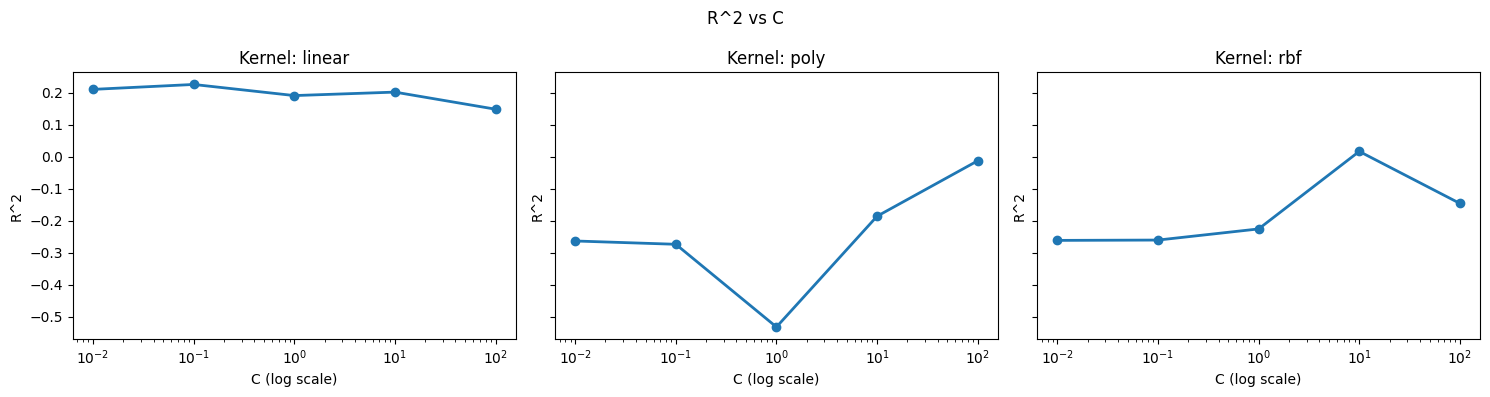

In [127]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel
# R2 vs C
C_sweep = [0.01, 0.1, 1, 10, 100]
reg_kernel_configs = {
    "linear": dict(kernel="linear"),
    "poly":   dict(kernel="poly", degree=3),
    "rbf":    dict(kernel="rbf", gamma="scale"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("R^2 vs C")

for ax, (name, params) in zip(axes, reg_kernel_configs.items()):
    r2_vals = []
    for C in C_sweep:
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler",  StandardScaler()),
            ("pca",     PCA(n_components=10)),
            ("model",   svm_regressor(C=C, **params)),
        ])
        cv = cross_val_score(pipe, X_reg, y_reg, cv=3, scoring="r2")
        r2_vals.append(cv.mean())
    ax.plot(C_sweep, r2_vals, marker="o", linewidth=2)
    ax.set_xscale("log")
    ax.set_xlabel("C (log scale)")
    ax.set_ylabel("R^2")
    ax.set_title(f"Kernel: {name}")

plt.tight_layout()
plt.savefig("reg_C_sensitivity.png")
plt.show()

PCA n=   5  R^2=-0.2028
PCA n=  10  R^2=0.0060
PCA n=  15  R^2=-0.0557
PCA n=  20  R^2=-0.0432
PCA n=  24  R^2=-0.0019


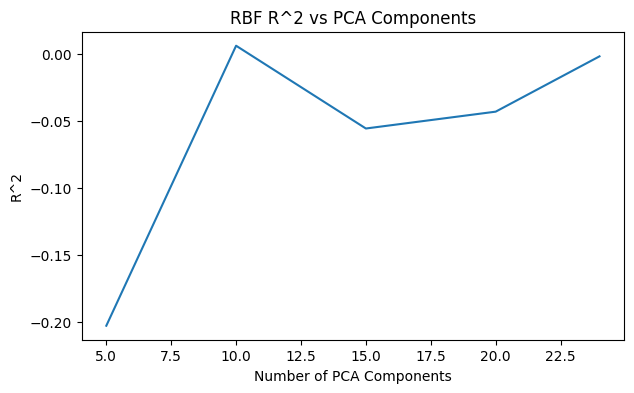

In [123]:

# r^2 vs PCA
pca_components = [5, 10, 15, 20, 24]
r2_pca = []

for n in pca_components:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
        ("pca",     PCA(n_components=n)),
        ("model",   svm_regressor(kernel="rbf", C=10, gamma="scale")),
    ])
    cv = cross_val_score(pipe, X_reg, y_reg, cv=3, scoring="r2")
    r2_pca.append(cv.mean())
    print(f"PCA n={n:>4}  R^2={cv.mean():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pca_components, r2_pca)
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("R^2")
ax.set_title("RBF R^2 vs PCA Components")
plt.savefig("reg_pca_sensitivity.png")
plt.show()